# DINOv3-L video-layer autocorrelation

This notebook extracts average-pooled DINOv3-L activations from video frames, computes layer-wise frame autocorrelation, and optionally compares video-level RDM time series across sampled clips.


In [1]:
import math
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from scipy.spatial.distance import squareform
from tqdm.auto import tqdm
from transformers import AutoImageProcessor


ENV = os.getenv("MY_ENV", "tiziano_mac_mini")


"""
find_project_root
Finds the nearest parent directory that contains config.yaml.

INPUT:
    - start_path: Path -> directory where the upward search starts

OUTPUT:
    - project_root: Path -> project directory containing config.yaml
"""
def find_project_root(start_path=Path.cwd()):
    start_path = Path(start_path).resolve()
    for candidate in (start_path, *start_path.parents):
        if (candidate / "config.yaml").exists():
            return candidate
        # end if config.yaml exists
    # end for candidate
    raise FileNotFoundError(f"Could not find config.yaml above {start_path}")
# EOF


PROJECT_ROOT = find_project_root()
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]

for src_path in (paths["src_path"], paths["useful_stuff_path"]):
    if src_path not in sys.path:
        sys.path.append(src_path)
    # end if src_path not in sys.path
# end for src_path

from useful_stuff.general_utils import TimeSeries, get_device
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.image_processing.computational_models import get_relevant_output_layers, imgANN


## Settings

Set `DINOV3_VIDEO_DIR` and optionally `DINOV3_VIDEO_PATH` in the environment, or edit the values below. Leaving `VIDEO_PATH = None` uses the first supported video in `VIDEO_DIR`.


In [2]:
from dataclasses import dataclass


@dataclass
class Cfg:
    model_name: str = "dino_v3_l"
    pkg: str = "hf"
    repo_url: str = "facebook/dinov3-vitl16-pretrain-lvd1689m"
    video_dir: str | Path = os.getenv("DINOV3_VIDEO_DIR", "~/Desktop/yes")
    video_path: str | Path | None = os.getenv("DINOV3_VIDEO_PATH")
    img_size: int = 224
    batch_size: int = 8
    frame_stride: int = 1
    max_frames: int | None = None
    lagplot_max_lag: int = 300
    rdm_video_subsample_size: int = 20
    rdm_n_timepoints: int = 75
    rdm_random_seed: int = 0
    rdm_metric: str = "cosine_cnt"
    rdm_rsa_metric: str = "correlation"
    cross_layer_target_layer_index: int = 16
    output_dir: str | Path = Path(paths["data_path"]) / "models" / "dinov3_autocorr_outputs"
    device: str = get_device()
    dtype: torch.dtype = torch.float32
# EOF


cfg = Cfg()

MODEL_NAME = cfg.model_name
PKG = cfg.pkg
REPO_URL = cfg.repo_url

VIDEO_DIR = Path(cfg.video_dir).expanduser()
VIDEO_PATH = Path(cfg.video_path).expanduser() if cfg.video_path else None

IMG_SIZE = cfg.img_size
BATCH_SIZE = cfg.batch_size
FRAME_STRIDE = cfg.frame_stride
MAX_FRAMES = cfg.max_frames
LAGPLOT_MAX_LAG = cfg.lagplot_max_lag

RDM_VIDEO_SUBSAMPLE_SIZE = cfg.rdm_video_subsample_size
RDM_N_TIMEPOINTS = cfg.rdm_n_timepoints
RDM_RANDOM_SEED = cfg.rdm_random_seed
RDM_METRIC = cfg.rdm_metric
RDM_RSA_METRIC = cfg.rdm_rsa_metric
CROSS_LAYER_TARGET_LAYER_INDEX = cfg.cross_layer_target_layer_index

OUTPUT_DIR = Path(cfg.output_dir).expanduser()

DEVICE = cfg.device
DTYPE = cfg.dtype

print(f"ENV: {ENV}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")


ENV: tiziano_mac_mini
Project root: /Users/tizianocausin/Desktop/static_dynamic
Device: mps


## Video Helpers


In [3]:
VIDEO_SUFFIXES = {".mp4", ".mov", ".m4v", ".avi", ".mkv"}


"""
list_video_paths
Lists supported video files in a directory.

INPUT:
    - video_dir: str | Path -> directory containing candidate videos

OUTPUT:
    - video_paths: list[Path] -> sorted supported video paths
"""
def list_video_paths(video_dir):
    video_dir = Path(video_dir).expanduser()
    if not video_dir.exists():
        raise FileNotFoundError(video_dir)
    # end if not video_dir.exists()

    return sorted(
        p for p in video_dir.iterdir()
        if p.is_file() and not p.name.startswith(".") and p.suffix.lower() in VIDEO_SUFFIXES
    )
# EOF


"""
choose_video
Selects a specific video path if provided, otherwise the first supported video in a directory.

INPUT:
    - video_dir: str | Path -> directory searched when video_path is None
    - video_path: str | Path | None -> explicit video path to use

OUTPUT:
    - selected_path: Path -> video file used for analysis
"""
def choose_video(video_dir, video_path=None):
    if video_path is not None:
        selected_path = Path(video_path).expanduser()
        if not selected_path.exists():
            raise FileNotFoundError(selected_path)
        # end if not selected_path.exists()
        return selected_path
    # end if video_path is not None

    video_paths = list_video_paths(video_dir)
    if not video_paths:
        raise FileNotFoundError(f"No supported videos found in {video_dir}")
    # end if not video_paths
    return video_paths[0]
# EOF


"""
read_video_frames
Decodes RGB frames from a video with optional temporal stride and frame cap.

INPUT:
    - video_path: str | Path -> video file to decode
    - frame_stride: int -> keep one frame every frame_stride frames
    - max_frames: int | None -> optional maximum number of kept frames

OUTPUT:
    - frames: list[np.ndarray] -> decoded RGB frames
    - sampling_rate: float -> effective frame rate after applying stride
"""
def read_video_frames(video_path, frame_stride=1, max_frames=None):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    # end if not cap.isOpened()

    fps = cap.get(cv2.CAP_PROP_FPS)
    if not fps or np.isnan(fps):
        fps = 30.0
    # end if not fps

    frames = []
    frame_idx = 0
    try:
        while True:
            ok, frame_bgr = cap.read()
            if not ok:
                break
            # end if not ok

            if frame_idx % frame_stride == 0:
                frames.append(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
                if max_frames is not None and len(frames) >= max_frames:
                    break
                # end if max_frames
            # end if frame_idx
            frame_idx += 1
        # end while True
    finally:
        cap.release()
    # end try

    if not frames:
        raise RuntimeError(f"No frames decoded from {video_path}")
    # end if not frames
    return frames, float(fps) / frame_stride
# EOF


video_path = choose_video(VIDEO_DIR, VIDEO_PATH)
frames_rgb, sampling_rate = read_video_frames(video_path, FRAME_STRIDE, MAX_FRAMES)

print(f"Video: {video_path}")
print(f"Frames used: {len(frames_rgb)}")
print(f"Sampling rate after stride: {sampling_rate:.3f} Hz")
print(f"First frame shape: {frames_rgb[0].shape}")


Video: /Users/tizianocausin/Desktop/yes/0_0_4117__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_735px_to_500x500.mp4
Frames used: 150
Sampling rate after stride: 60.000 Hz
First frame shape: (500, 500, 3)


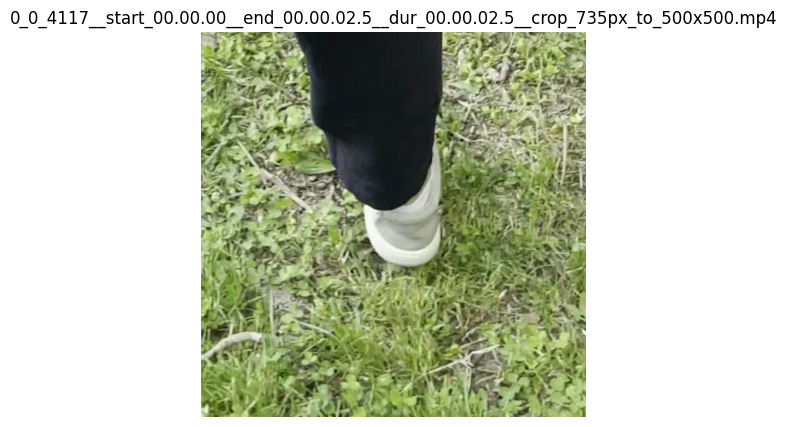

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(frames_rgb[0])
ax.set_title(video_path.name)
ax.axis("off");


## Extract Average-Pooled DINOv3-L Features

The hook uses `pooling="mean"`, so token activations from each selected layer are average-pooled into one feature vector per frame.


In [5]:
image_processor = AutoImageProcessor.from_pretrained(REPO_URL)
layers = get_relevant_output_layers(MODEL_NAME, pkg=PKG)
if not 0 <= CROSS_LAYER_TARGET_LAYER_INDEX < len(layers):
    raise ValueError(
        f"CROSS_LAYER_TARGET_LAYER_INDEX must be between 0 and {len(layers) - 1}; "
        f"got {CROSS_LAYER_TARGET_LAYER_INDEX}"
    )
# end if CROSS_LAYER_TARGET_LAYER_INDEX

ann = imgANN(
    model_name=MODEL_NAME,
    pkg=PKG,
    img_size=IMG_SIZE,
    relevant_layers=layers,
    pooling="mean",
    dtype=DTYPE,
    attn_implementation="sdpa",
    repo_url=REPO_URL,
    device=DEVICE,
)
ann.model.eval()
ann.create_forward_hook(layers)

print(f"{len(layers)} layers")
print(image_processor)
print(layers[:3], layers[-3:])


24 layers
DINOv3ViTImageProcessorFast {
  "crop_size": null,
  "data_format": "channels_first",
  "default_to_square": true,
  "device": null,
  "disable_grouping": null,
  "do_center_crop": null,
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_pad": null,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "input_data_format": null,
  "pad_size": null,
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "return_tensors": null,
  "size": {
    "height": 224,
    "width": 224
  }
}

['layer.0.mlp.down_proj', 'layer.1.mlp.down_proj', 'layer.2.mlp.down_proj'] ['layer.21.mlp.down_proj', 'layer.22.mlp.down_proj', 'layer.23.mlp.down_proj']


In [6]:
"""
batched
Yields consecutive batches from a sequence.

INPUT:
    - items: sequence -> items to batch
    - batch_size: int -> number of items per batch

OUTPUT:
    - batches: generator[tuple[int, sequence]] -> start index and batch slice
"""
def batched(items, batch_size):
    for start in range(0, len(items), batch_size):
        yield start, items[start:start + batch_size]
    # end for start
# EOF


"""
clear_model_cache
Releases cached accelerator memory after feature extraction batches.

INPUT:
    - device: str | torch.device -> active compute device

OUTPUT:
    - None
"""
def clear_model_cache(device):
    device = str(device)
    if device.startswith("cuda"):
        torch.cuda.empty_cache()
    elif device == "mps":
        torch.mps.empty_cache()
    # end if device
    return None
# EOF


"""
extract_dinov3_features_from_frames
Extracts hooked DINOv3 features from a list of RGB frames.

INPUT:
    - frames: list[np.ndarray] -> RGB video frames
    - ann: imgANN -> model wrapper with registered forward hooks
    - image_processor: AutoImageProcessor -> DINOv3 image preprocessor
    - layers: list[str] -> hooked layer names to collect
    - batch_size: int -> number of frames passed per forward call
    - device: str | torch.device -> compute device
    - dtype: torch.dtype -> tensor dtype used for model inputs
    - desc: str -> tqdm progress label

OUTPUT:
    - features_by_layer: dict[str, np.ndarray] -> layer activations as time x features arrays
"""
def extract_dinov3_features_from_frames(frames, ann, image_processor, layers, batch_size, device, dtype, desc):
    features_by_layer = {layer: [] for layer in layers}

    with torch.inference_mode():
        for _, batch_frames in tqdm(list(batched(frames, batch_size)), desc=desc, leave=False):
            inputs = image_processor(images=batch_frames, return_tensors="pt")
            batch = inputs["pixel_values"].to(device, dtype=dtype)

            # HuggingFace ViT-style models accept DINO-preprocessed pixel_values directly.
            _ = ann.model(pixel_values=batch)

            for layer in layers:
                layer_features = ann.features[layer]
                if layer_features is None:
                    raise RuntimeError(f"Hook did not capture features for {layer}")
                # end if layer_features is None
                features_by_layer[layer].append(layer_features.detach().float().cpu().numpy())
                ann.features[layer] = None
            # end for layer

            del inputs, batch
            clear_model_cache(device)
        # end for batch_frames
    # end with torch.inference_mode()

    return {
        layer: np.concatenate(chunks, axis=0)
        for layer, chunks in features_by_layer.items()
    }
# EOF


features_by_layer = extract_dinov3_features_from_frames(
    frames_rgb,
    ann,
    image_processor,
    layers,
    BATCH_SIZE,
    DEVICE,
    DTYPE,
    desc="DINOv3-L batches",
)

print("Layer feature shapes:")
for layer, arr in list(features_by_layer.items())[:3]:
    print(layer, arr.shape)
# end for layer
print("...")
for layer, arr in list(features_by_layer.items())[-3:]:
    print(layer, arr.shape)
# end for layer


DINOv3-L batches:   0%|          | 0/19 [00:00<?, ?it/s]

Layer feature shapes:
layer.0.mlp.down_proj (150, 1024)
layer.1.mlp.down_proj (150, 1024)
layer.2.mlp.down_proj (150, 1024)
...
layer.21.mlp.down_proj (150, 1024)
layer.22.mlp.down_proj (150, 1024)
layer.23.mlp.down_proj (150, 1024)


## Compute Full Autocorrelation Matrices

`TimeSeries` expects arrays as `features x time`, so each layer's `time x features` activation matrix is transposed before calling `.autocorr()`.


In [7]:
timeseries_by_layer = {}
autocorr_by_layer = {}
lagplot_by_layer = {}

for layer, feature_matrix in features_by_layer.items():
    ts = TimeSeries(feature_matrix.T, fs=sampling_rate)
    max_lag = max(1, min(LAGPLOT_MAX_LAG, len(ts) - 1))
    ac_mat, ac_decay = ts.autocorr(max_lag=max_lag)
    timeseries_by_layer[layer] = ts
    autocorr_by_layer[layer] = ac_mat
    lagplot_by_layer[layer] = ac_decay
# end for layer

example_layer = layers[-1]
print(example_layer, autocorr_by_layer[example_layer].shape, lagplot_by_layer[example_layer].shape)


16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of datapoints used to compute extreme offsets is < than 10
16:56:07 - The number of dat

## Plot Layer Autocorrelation


In [8]:
"""
short_layer_name
Compacts DINOv3 layer names for plot labels.

INPUT:
    - layer: str -> full layer name

OUTPUT:
    - name: str -> compact layer label
"""
def short_layer_name(layer):
    name = layer.replace("layer.", "L").replace(".mlp.down_proj", "")
    return name
# EOF


"""
layer_plot_colors
Builds one color per model layer from a Matplotlib colormap.

INPUT:
    - layers: list[str] -> layer names
    - cmap_name: str -> Matplotlib colormap name

OUTPUT:
    - cmap: Colormap -> Matplotlib colormap object
    - colors: np.ndarray -> color array with one row per layer
"""
def layer_plot_colors(layers, cmap_name="plasma"):
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0.05, 0.95, len(layers)))
    return cmap, colors
# EOF


"""
add_layer_colorbar
Adds a layer-index colorbar to a Matplotlib axis.

INPUT:
    - fig: matplotlib.figure.Figure -> active figure
    - ax: matplotlib.axes.Axes -> axis receiving the colorbar
    - layers: list[str] -> layer names represented by the colormap
    - cmap: Colormap -> colormap used by the plotted layer curves
    - label: str -> colorbar label

OUTPUT:
    - cbar: matplotlib.colorbar.Colorbar -> created colorbar
"""
def add_layer_colorbar(fig, ax, layers, cmap, label="DINOv3-L layer index"):
    norm = plt.Normalize(vmin=0, vmax=len(layers) - 1)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(label)
    cbar.set_ticks([0, len(layers) - 1])
    cbar.set_ticklabels([short_layer_name(layers[0]), short_layer_name(layers[-1])])
    return cbar
# EOF


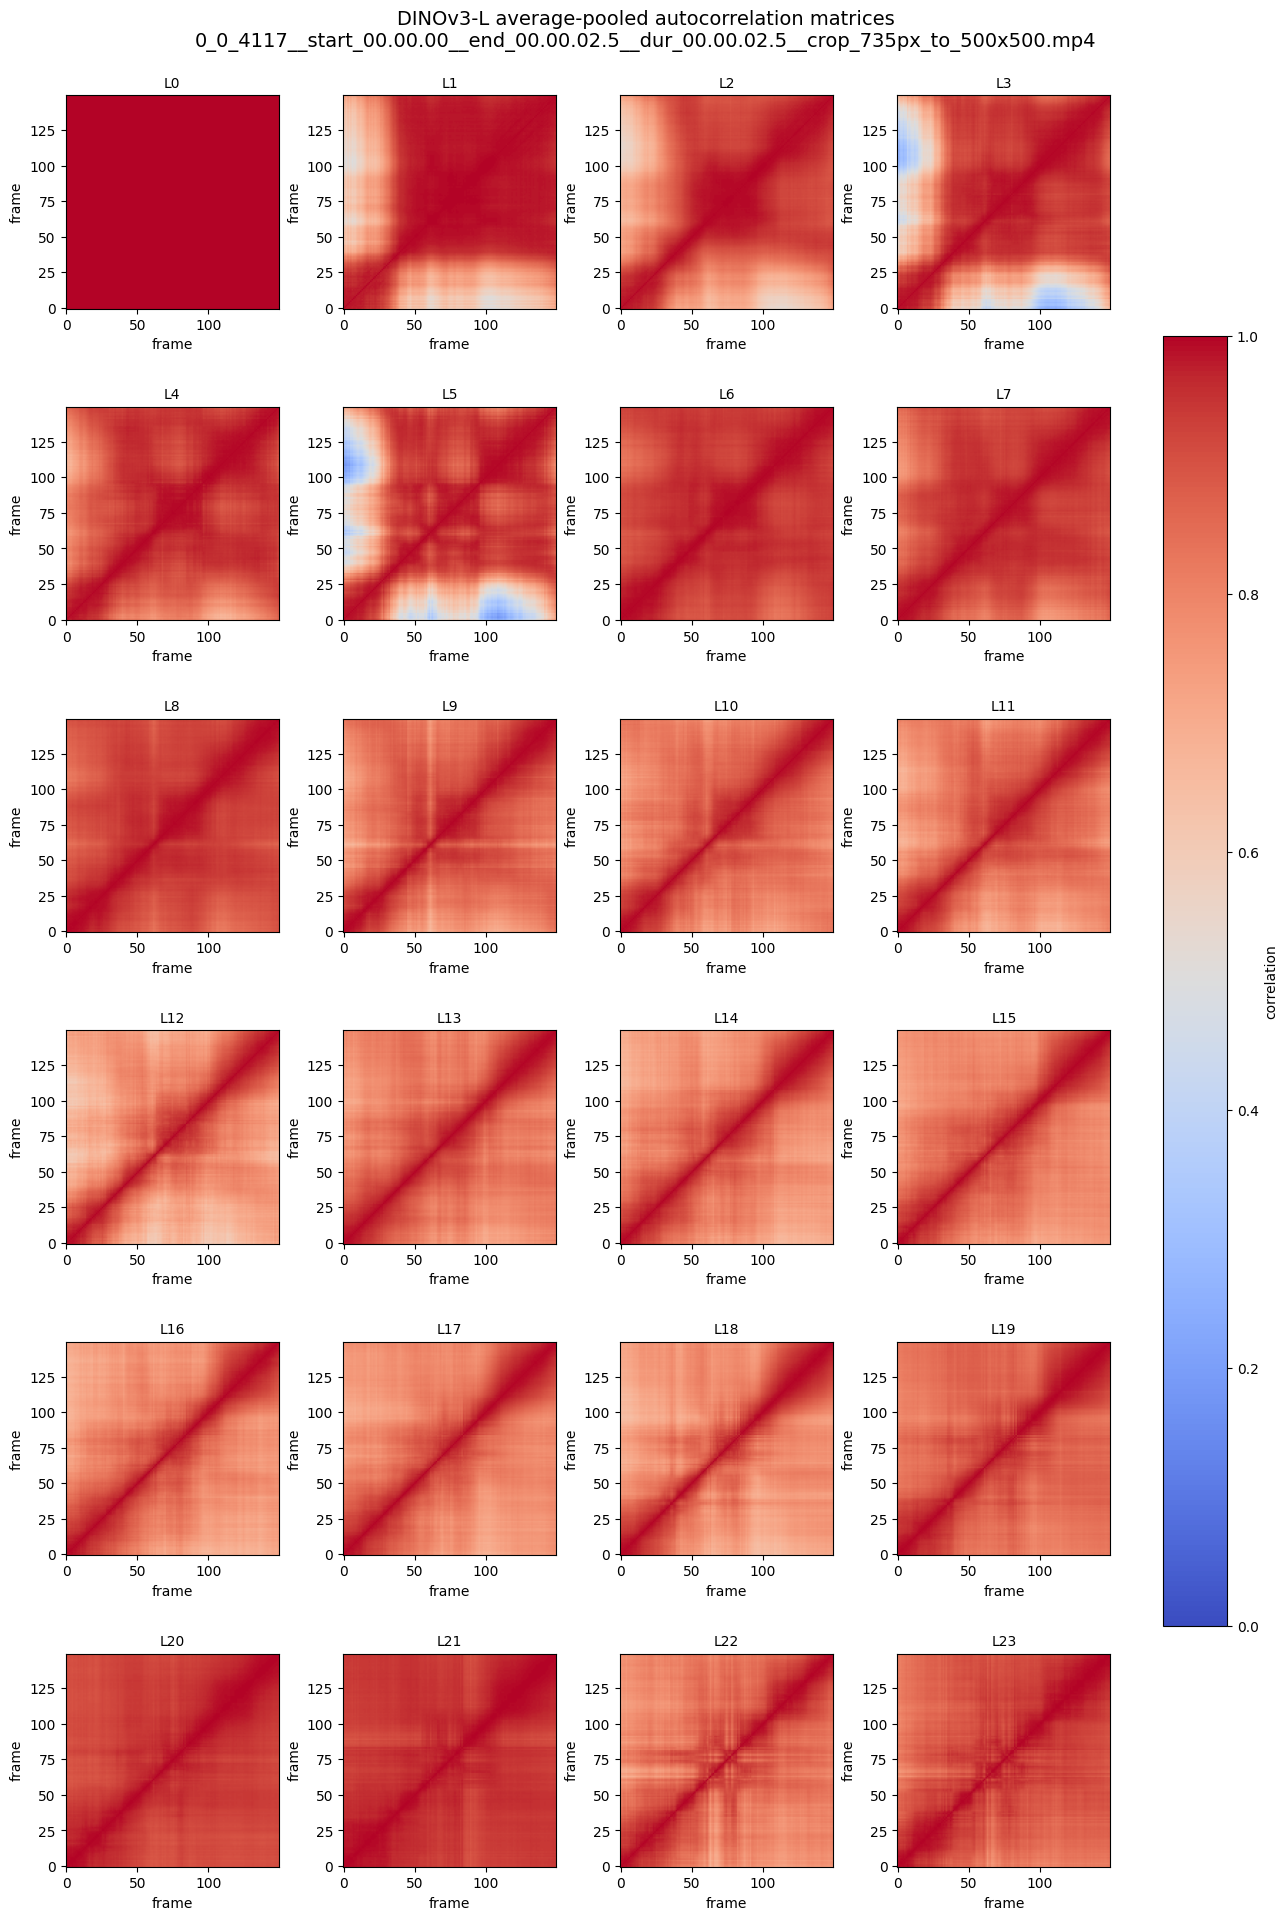

In [9]:
n_layers = len(layers)
ncols = 4
nrows = math.ceil(n_layers / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows), constrained_layout=True)
axes = np.asarray(axes).ravel()

im = None
for ax, layer in zip(axes, layers):
    im = ax.imshow(autocorr_by_layer[layer], vmin=0, vmax=1, cmap="coolwarm", origin="lower")
    ax.set_title(short_layer_name(layer), fontsize=10)
    ax.set_xlabel("frame")
    ax.set_ylabel("frame")
# end for ax

for ax in axes[n_layers:]:
    ax.axis("off")
# end for ax

fig.suptitle(f"DINOv3-L average-pooled autocorrelation matrices\n{video_path.name}", fontsize=14)
fig.colorbar(im, ax=axes[:n_layers], shrink=0.7, label="correlation")
plt.show()


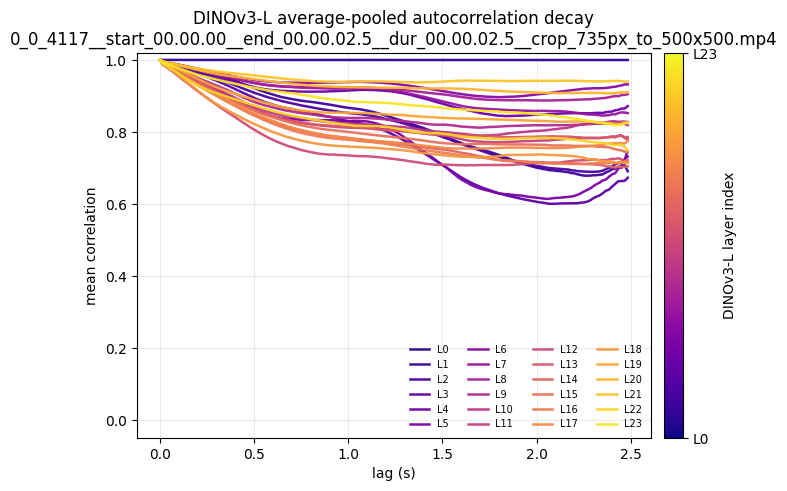

In [10]:
cmap, colors = layer_plot_colors(layers)

fig, ax = plt.subplots(figsize=(8, 5))
for layer, color in zip(layers, colors):
    decay = lagplot_by_layer[layer]
    lag_seconds = np.arange(len(decay)) / sampling_rate
    ax.plot(
        lag_seconds,
        decay,
        color=color,
        linewidth=1.8,
        alpha=0.95,
        label=short_layer_name(layer),
    )
# end for layer

ax.set_title(f"DINOv3-L average-pooled autocorrelation decay\n{video_path.name}")
ax.set_xlabel("lag (s)")
ax.set_ylabel("mean correlation")
ax.set_ylim(-0.05, 1.02)
ax.grid(True, alpha=0.25)
add_layer_colorbar(fig, ax, layers, cmap)
ax.legend(ncol=4, fontsize=7, frameon=False, loc="lower right")
plt.show()


## Correlation To The Final Frame

For each DINOv3-L layer, this computes the Pearson correlation between every frame feature vector and the feature vector of the last frame.


In [11]:
"""
correlate_rows_to_reference
Computes row-wise Pearson correlations to one reference vector.

INPUT:
    - feature_matrix: np.ndarray -> matrix shaped observations x features
    - reference_vector: np.ndarray -> reference vector with matching feature dimension

OUTPUT:
    - correlations: np.ndarray -> one correlation per feature_matrix row
"""
def correlate_rows_to_reference(feature_matrix, reference_vector):
    x = np.asarray(feature_matrix, dtype=np.float64)
    ref = np.asarray(reference_vector, dtype=np.float64)

    x_centered = x - x.mean(axis=1, keepdims=True)
    ref_centered = ref - ref.mean()

    numerator = x_centered @ ref_centered
    denominator = np.linalg.norm(x_centered, axis=1) * np.linalg.norm(ref_centered)
    correlations = np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan, dtype=np.float64),
        where=denominator > 0,
    )
    return correlations
# EOF


corr_to_last_by_layer = {
    layer: correlate_rows_to_reference(feature_matrix, feature_matrix[-1])
    for layer, feature_matrix in features_by_layer.items()
}

n_frames = next(iter(features_by_layer.values())).shape[0]
frame_offsets_to_last = np.arange(n_frames) - (n_frames - 1)
time_offsets_to_last = frame_offsets_to_last / sampling_rate

example_layer = layers[-1]
print(example_layer, corr_to_last_by_layer[example_layer].shape)
print(f"Final-frame self-correlation: {corr_to_last_by_layer[example_layer][-1]:.3f}")


layer.23.mlp.down_proj (150,)
Final-frame self-correlation: 1.000


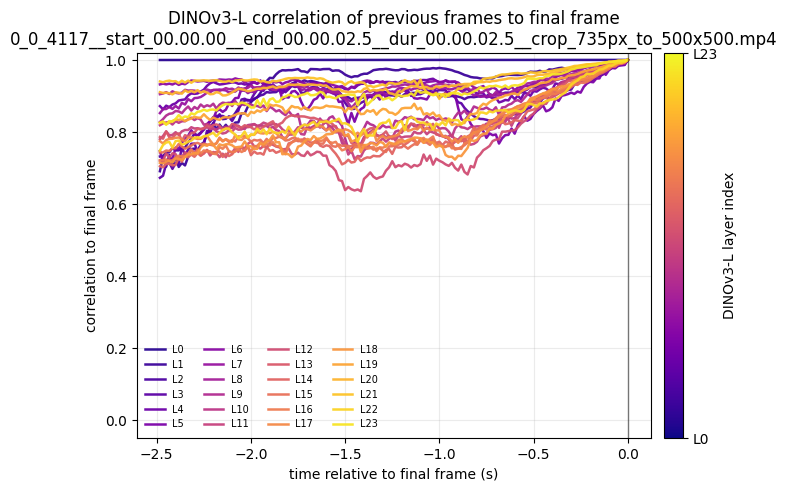

In [12]:
cmap, colors = layer_plot_colors(layers)

fig, ax = plt.subplots(figsize=(8, 5))
for layer, color in zip(layers, colors):
    ax.plot(
        time_offsets_to_last,
        corr_to_last_by_layer[layer],
        color=color,
        linewidth=1.8,
        alpha=0.95,
        label=short_layer_name(layer),
    )
# end for layer

ax.axvline(0, color="black", linewidth=1, alpha=0.5)
ax.set_title(f"DINOv3-L correlation of previous frames to final frame\n{video_path.name}")
ax.set_xlabel("time relative to final frame (s)")
ax.set_ylabel("correlation to final frame")
ax.set_ylim(-0.05, 1.02)
ax.grid(True, alpha=0.25)
add_layer_colorbar(fig, ax, layers, cmap)
ax.legend(ncol=4, fontsize=7, frameon=False, loc="lower left")
plt.show()


## Multi-Video RDMs And Final-Frame dRSA

This section randomly samples videos from `VIDEO_DIR`, extracts DINOv3-L activations for uniformly spaced frames in each video, computes one RDM across videos at each time point for every layer using `dRSA`, and correlates each previous RDM with the final-frame RDM.


In [13]:
"""
uniformly_sample_frames
Samples a fixed number of approximately evenly spaced frames.

INPUT:
    - frames: list[np.ndarray] -> decoded video frames
    - n_timepoints: int -> number of frames to sample

OUTPUT:
    - sampled_frames: list[np.ndarray] -> selected frames
    - frame_idx: np.ndarray -> selected source-frame indices
"""
def uniformly_sample_frames(frames, n_timepoints):
    if len(frames) == 0:
        raise RuntimeError("Cannot sample from an empty frame list")
    # end if len(frames) == 0

    frame_idx = np.linspace(0, len(frames) - 1, n_timepoints).round().astype(int)
    sampled_frames = [frames[i] for i in frame_idx]
    return sampled_frames, frame_idx
# EOF


all_rdm_video_paths = list_video_paths(VIDEO_DIR)
if len(all_rdm_video_paths) < 2:
    raise RuntimeError(f"Need at least 2 videos to compute an RDM, found {len(all_rdm_video_paths)}")
# end if len(all_rdm_video_paths) < 2

rng = np.random.default_rng(RDM_RANDOM_SEED)
rdm_sample_size = min(RDM_VIDEO_SUBSAMPLE_SIZE, len(all_rdm_video_paths))
sampled_video_indices = rng.choice(len(all_rdm_video_paths), size=rdm_sample_size, replace=False)
rdm_video_paths = [all_rdm_video_paths[i] for i in sampled_video_indices]

print(f"Using {len(rdm_video_paths)} videos for RDMs:")
for p in rdm_video_paths:
    print("  ", p.name)
# end for p

rdm_sampled_video_features = {}
rdm_sampled_frame_indices = {}
for p in tqdm(rdm_video_paths, desc="Sampled videos"):
    video_frames, _ = read_video_frames(p, frame_stride=1, max_frames=None)
    sampled_frames, sampled_idx = uniformly_sample_frames(video_frames, RDM_N_TIMEPOINTS)
    rdm_sampled_frame_indices[str(p)] = sampled_idx
    rdm_sampled_video_features[p] = extract_dinov3_features_from_frames(
        sampled_frames,
        ann,
        image_processor,
        layers,
        BATCH_SIZE,
        DEVICE,
        DTYPE,
        desc=p.name,
    )
# end for p

print("Finished extracting sampled-video features.")


Using 20 videos for RDMs:
   these_cats_are_too_funny_00_27_19_5__start_00.00.00.37__end_00.00.02.87__dur_00.00.02.5__crop_500px_to_500x500.mp4
   cats_n_kittens_00_01_59__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_1025px_to_500x500.mp4
   bandaro_00_02_32_5__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_1025px_to_500x500.mp4
   what_happens_when_animals_00_03_30_5__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_725px_to_500x500.mp4
   hilarious_dogs_00_10_30__start_00.00.01.904__end_00.00.04.404__dur_00.00.02.5__crop_350px_to_500x500.mp4
   monkeys_n_apes_00_02_19__start_00.00.00.42__end_00.00.02.92__dur_00.00.02.5__crop_1275px_to_500x500.mp4
   monkey_uses_both_hands_and_feet_00_03_48__start_00.00.02.1__end_00.00.04.6__dur_00.00.02.5__crop_1080px_to_500x500.mp4
   watch_these_adorable_monkeys_00_21_00__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_500px_to_500x500.mp4
   majestic_wildlife_4k_00_13_05__start_00.00.01.738__end_00.00.04.238__dur_00.00.02.5_

Sampled videos:   0%|          | 0/20 [00:00<?, ?it/s]

these_cats_are_too_funny_00_27_19_5__start_00.00.00.37__end_00.00.02.87__dur_00.00.02.5__crop_500px_to_500x500…

cats_n_kittens_00_01_59__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_1025px_to_500x500.mp4:   0%|    …

bandaro_00_02_32_5__start_00.00.00__end_00.00.02.5__dur_00.00.02.5__crop_1025px_to_500x500.mp4:   0%|         …

...

no_oven_in_our_village_00_01_44__start_00.00.01.967__end_00.00.04.467__dur_00.00.02.5__crop_1150px_to_500x500.…

hunter_animals_00_04_40__start_00.00.01.45__end_00.00.03.95__dur_00.00.02.5__crop_1000px_to_500x500.mp4:   0%|…

owls_are_so_funny_00_01_58__start_00.00.00.002__end_00.00.02.502__dur_00.00.02.5__crop_650px_to_500x500.mp4:  …

43.81_4141__crop_1225px_to_500x500.mp4:   0%|          | 0/10 [00:00<?, ?it/s]

Finished extracting sampled-video features.


In [14]:
rdm_timeseries_by_layer = {}
rdm_corr_to_final_by_layer = {}
drsa_by_layer = {}

for layer in tqdm(layers, desc="Layer RDM time series"):
    # Stack as videos x time x features, then transpose to features x time x videos.
    video_time_feature = np.stack(
        [rdm_sampled_video_features[p][layer] for p in rdm_video_paths],
        axis=0,
    )
    layer_signal = TimeSeries(np.transpose(video_time_feature, (2, 1, 0)), fs=RDM_N_TIMEPOINTS)

    layer_drsa = dRSA(
        signal_RDM_metric=RDM_METRIC,
        RSA_metric=RDM_RSA_METRIC,
    )
    layer_drsa.compute_RDM_timeseries(layer_signal, RDM_type="signal")

    # Use the final time-point RDM as the static reference RDM.
    layer_drsa.model_RDM = layer_drsa.signal_RDM_timeseries.array[-1]
    static_drsa = layer_drsa.compute_static_dRSA()

    rdm_timeseries_by_layer[layer] = layer_drsa.signal_RDM_timeseries
    rdm_corr_to_final_by_layer[layer] = static_drsa.array
    drsa_by_layer[layer] = layer_drsa
# end for layer

rdm_normalized_time_to_final = np.linspace(-1, 0, RDM_N_TIMEPOINTS)
example_layer = layers[-1]
print(example_layer, rdm_corr_to_final_by_layer[example_layer].shape)
print(f"Final RDM self-correlation: {rdm_corr_to_final_by_layer[example_layer][-1]:.3f}")


Layer RDM time series:   0%|          | 0/24 [00:00<?, ?it/s]

layer.23.mlp.down_proj (75,)
Final RDM self-correlation: 1.000


## Cross-Layer RDM Correlation To A Target Final-Frame RDM

For target layer `CROSS_LAYER_TARGET_LAYER_INDEX`, this correlates every source layer RDM at every time point with the target layer RDM at the final frame.


In [15]:
target_rdm_layer = layers[CROSS_LAYER_TARGET_LAYER_INDEX]
target_final_rdm = rdm_timeseries_by_layer[target_rdm_layer].array[-1]

cross_layer_rdm_corr_to_target_final = {}
for layer in layers:
    layer_rdm_ts = rdm_timeseries_by_layer[layer]
    layer_rdm_array = np.stack(layer_rdm_ts.array, axis=0)
    cross_layer_rdm_corr_to_target_final[layer] = correlate_rows_to_reference(
        layer_rdm_array,
        target_final_rdm,
    )
# end for layer

print(f"Target RDM layer: {target_rdm_layer}")
print(f"Target final-frame RDM length: {target_final_rdm.shape[0]}")
print(f"Computed RDM-to-target-final correlations for {len(cross_layer_rdm_corr_to_target_final)} layers.")
print(f"Target final-RDM self-correlation: {cross_layer_rdm_corr_to_target_final[target_rdm_layer][-1]:.3f}")


Target RDM layer: layer.16.mlp.down_proj
Target final-frame RDM length: 190
Computed RDM-to-target-final correlations for 24 layers.
Target final-RDM self-correlation: 1.000


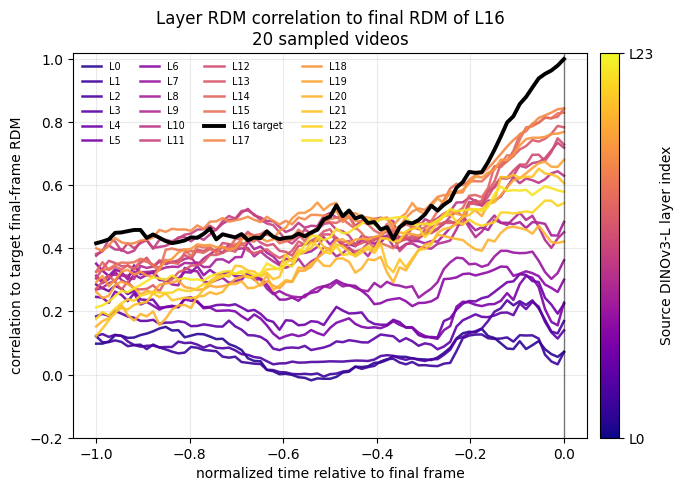

In [16]:
cmap, colors = layer_plot_colors(layers)

fig, ax = plt.subplots(figsize=(8, 5))
for layer, color in zip(layers, colors):
    is_target = layer == target_rdm_layer
    ax.plot(
        rdm_normalized_time_to_final,
        cross_layer_rdm_corr_to_target_final[layer],
        color="black" if is_target else color,
        linewidth=2.8 if is_target else 1.8,
        alpha=1.0 if is_target else 0.9,
        label=f"{short_layer_name(layer)} target" if is_target else short_layer_name(layer),
        zorder=3 if is_target else 2,
    )
# end for layer

ax.axvline(0, color="black", linewidth=1, alpha=0.5)
ax.set_title(f"Layer RDM correlation to final RDM of {short_layer_name(target_rdm_layer)}\n{len(rdm_video_paths)} sampled videos")
ax.set_xlabel("normalized time relative to final frame")
ax.set_ylabel("correlation to target final-frame RDM")
ax.set_ylim(-0.2, 1.02)
ax.grid(True, alpha=0.25)
add_layer_colorbar(fig, ax, layers, cmap, label="Source DINOv3-L layer index")
ax.legend(ncol=4, fontsize=7, frameon=False, loc="upper left")
plt.show()


## RDM Autocorrelation Lagplots

The vectorized RDMs form a time series for each layer. This computes the full RDM autocorrelation matrix and diagonal-averaged lagplot with `TimeSeries.autocorr()`.


In [17]:
rdm_autocorr_by_layer = {}
rdm_lagplot_by_layer = {}

for layer in layers:
    rdm_ts = rdm_timeseries_by_layer[layer]
    rdm_array = np.stack(rdm_ts.array, axis=0)
    rdm_vector_ts = TimeSeries(rdm_array.T, fs=RDM_N_TIMEPOINTS)
    max_lag = max(1, min(LAGPLOT_MAX_LAG, len(rdm_vector_ts) - 1))
    ac_mat, ac_decay = rdm_vector_ts.autocorr(max_lag=max_lag)
    rdm_autocorr_by_layer[layer] = ac_mat
    rdm_lagplot_by_layer[layer] = ac_decay
# end for layer

example_layer = layers[-1]
print(example_layer, rdm_autocorr_by_layer[example_layer].shape, rdm_lagplot_by_layer[example_layer].shape)


16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of datapoints used to compute extreme offsets is < than 10
16:57:54 - The number of dat

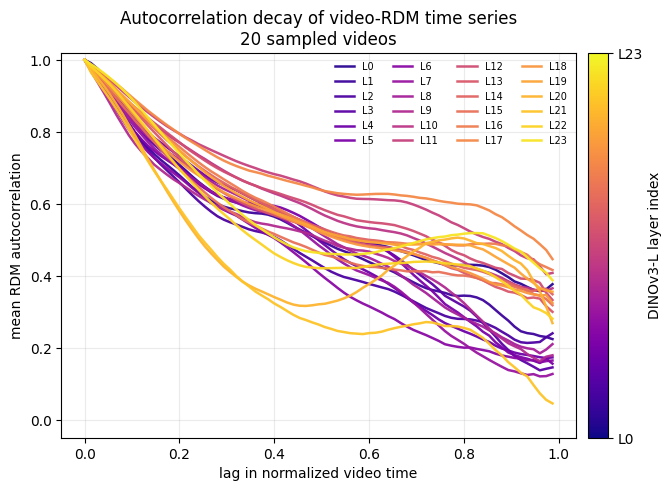

In [18]:
cmap, colors = layer_plot_colors(layers)

fig, ax = plt.subplots(figsize=(8, 5))
for layer, color in zip(layers, colors):
    decay = rdm_lagplot_by_layer[layer]
    lag_normalized_time = np.arange(len(decay)) / RDM_N_TIMEPOINTS
    ax.plot(
        lag_normalized_time,
        decay,
        color=color,
        linewidth=1.8,
        alpha=0.95,
        label=short_layer_name(layer),
    )
# end for layer

ax.set_title(f"Autocorrelation decay of video-RDM time series\n{len(rdm_video_paths)} sampled videos")
ax.set_xlabel("lag in normalized video time")
ax.set_ylabel("mean RDM autocorrelation")
ax.set_ylim(-0.05, 1.02)
ax.grid(True, alpha=0.25)
add_layer_colorbar(fig, ax, layers, cmap)
ax.legend(ncol=4, fontsize=7, frameon=False, loc="upper right")
plt.show()


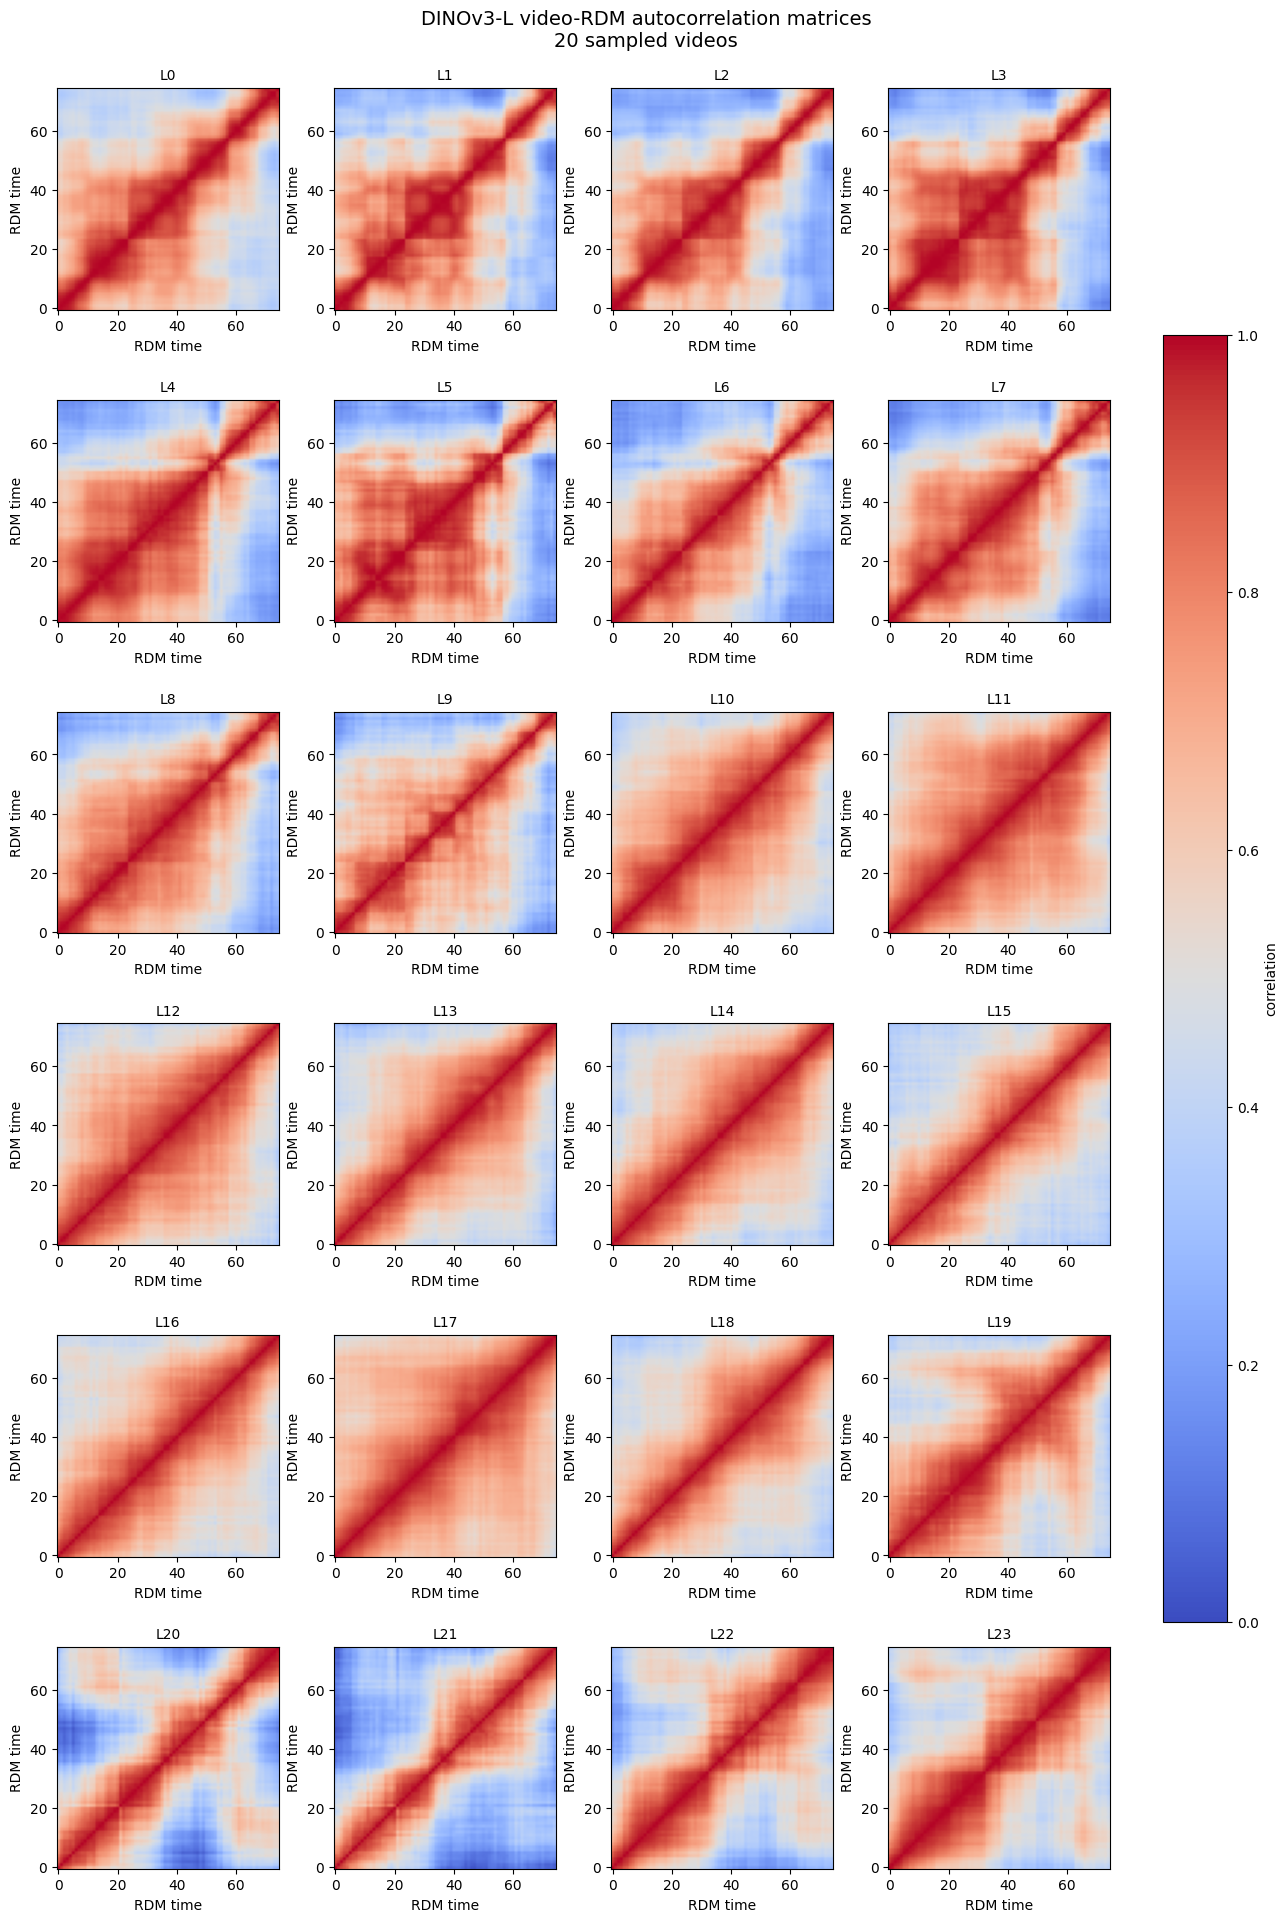

In [19]:
n_layers = len(layers)
ncols = 4
nrows = math.ceil(n_layers / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows), constrained_layout=True)
axes = np.asarray(axes).ravel()

im = None
for ax, layer in zip(axes, layers):
    im = ax.imshow(rdm_autocorr_by_layer[layer], vmin=0, vmax=1, cmap="coolwarm", origin="lower")
    ax.set_title(short_layer_name(layer), fontsize=10)
    ax.set_xlabel("RDM time")
    ax.set_ylabel("RDM time")
# end for ax

for ax in axes[n_layers:]:
    ax.axis("off")
# end for ax

fig.suptitle(f"DINOv3-L video-RDM autocorrelation matrices\n{len(rdm_video_paths)} sampled videos", fontsize=14)
fig.colorbar(im, ax=axes[:n_layers], shrink=0.7, label="correlation")
plt.show()


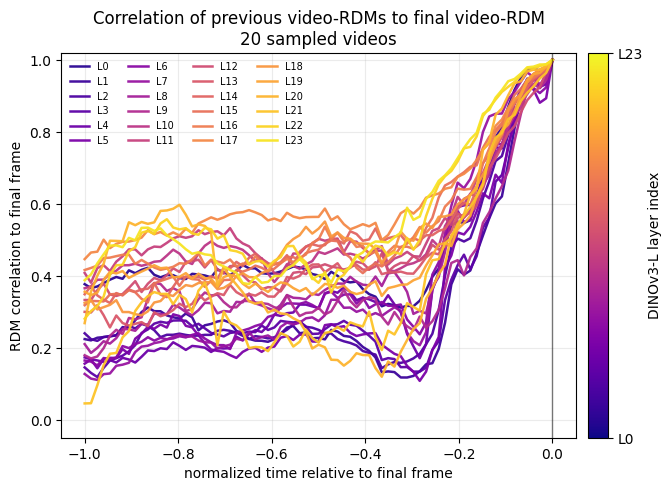

In [20]:
cmap, colors = layer_plot_colors(layers)

fig, ax = plt.subplots(figsize=(8, 5))
for layer, color in zip(layers, colors):
    ax.plot(
        rdm_normalized_time_to_final,
        rdm_corr_to_final_by_layer[layer],
        color=color,
        linewidth=1.8,
        alpha=0.95,
        label=short_layer_name(layer),
    )
# end for layer

ax.axvline(0, color="black", linewidth=1, alpha=0.5)
ax.set_title(f"Correlation of previous video-RDMs to final video-RDM\n{len(rdm_video_paths)} sampled videos")
ax.set_xlabel("normalized time relative to final frame")
ax.set_ylabel("RDM correlation to final frame")
ax.set_ylim(-0.05, 1.02)
ax.grid(True, alpha=0.25)
add_layer_colorbar(fig, ax, layers, cmap)
ax.legend(ncol=4, fontsize=7, frameon=False, loc="upper left")
plt.show()


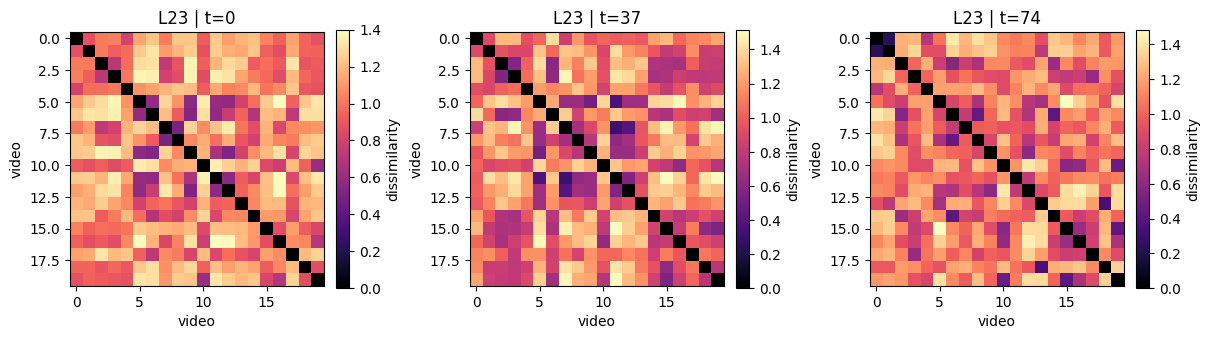

In [21]:
selected_rdm_layer = layers[-1]
time_indices_to_show = [0, RDM_N_TIMEPOINTS // 2, RDM_N_TIMEPOINTS - 1]

fig, axes = plt.subplots(1, len(time_indices_to_show), figsize=(4 * len(time_indices_to_show), 3.5), constrained_layout=True)
if len(time_indices_to_show) == 1:
    axes = [axes]
# end if len(time_indices_to_show) == 1

vmax = 2 if RDM_METRIC == "correlation" else None
for ax, t_idx in zip(axes, time_indices_to_show):
    rdm_square = squareform(rdm_timeseries_by_layer[selected_rdm_layer].array[t_idx])
    im = ax.imshow(rdm_square, cmap="magma", vmin=0, vmax=vmax)
    ax.set_title(f"{short_layer_name(selected_rdm_layer)} | t={t_idx}")
    ax.set_xlabel("video")
    ax.set_ylabel("video")
    fig.colorbar(im, ax=ax, shrink=0.8, label="dissimilarity")
# end for ax

plt.show()
